In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import glob
import re
import unicodedata
from sklearn.model_selection import train_test_split

RANDOM_STATE = 5
import time

In [2]:
files = glob.glob("data/*.csv")

day_re = "/([a-zA-Z]*)-"

def read_day_csv(f):
    df = pd.read_csv(f, encoding_errors="replace")
    df["day"] = re.search(day_re, f).group(1)
    return df

df = (
    pd.concat((read_day_csv(f) for f in files), ignore_index=True)
    .rename(columns=lambda s: s.strip())
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

df = df.drop(columns=["Destination Port", "Init_Win_bytes_forward",
            "Fwd Header Length", "Total Fwd Packets", "min_seg_size_forward",
            "SYN Flag Count", "Bwd Packet Length Mean"])

# Safely downcasts 64-bit data to 32-bit where there is no information loss
def down_cast(d):
    original_size = d.memory_usage(deep=True).sum()
    for col in d.select_dtypes("integer").columns:
        d[col] = pd.to_numeric(d[col], downcast="integer")
    for col in d.select_dtypes("float").columns:
        d[col] = pd.to_numeric(d[col], downcast="float")
    final_size = d.memory_usage(deep=True).sum()
    return d
df = down_cast(df)

def normalise(s):
    return (unicodedata.normalize("NFKD", str(s))
            .encode("ascii", "ignore")
            .decode("ascii"))
df["Label"] = df["Label"].apply(normalise)

train_days = df["day"].isin(["Monday", "Tuesday", "Wednesday"])
train = df[train_days]
test  = df[~train_days]

train_attacks = set(train["Label"]) - {"BENIGN"}
test_attacks  = set(test["Label"])  - {"BENIGN"}
novel         = test_attacks - train_attacks

X_train = train.drop(columns=["Label", "day"])
X_test  = test.drop(columns=["Label", "day"])

y_train_attackname = train["Label"]
y_test_attackname  = test["Label"]

multi_to_binary = lambda name: 0 if (name=="BENIGN") else 1
y_train = y_train_attackname.map(multi_to_binary)
y_test = y_test_attackname.map(multi_to_binary)

X_train, X_cv, y_train, y_cv = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

# For XGBoost, don't need scaling
# from sklearn.preprocessing import StandardScaler
# std_scaler = StandardScaler().fit(X_train)
# X_train = std_scaler.transform(X_train)
# X_cv    = std_scaler.transform(X_cv)
# X_test  = std_scaler.transform(X_test)

In [6]:
from sklearn.metrics import classification_report

def evaluate(preds, y, target_names, title=""):
    print(f"--- {title} ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=target_names))
    
hyper_params = {"n_estimators": 300, "learning_rate": 0.1, "verbosity": 1,
             "random_state": RANDOM_STATE,  "early_stopping_rounds": 20, "tree_method": "hist"}
eval_set = [(X_cv, y_cv)]

xgb_model = XGBClassifier(**hyper_params)
xgb_model.fit(X_train, y_train, eval_set = eval_set, verbose=0)

preds = xgb_model.predict(X_test)
evaluate(preds, y_test, ["benign", "anomaly"], "baseline")


--- baseline ---
accuracy: 0.7426
              precision    recall  f1-score   support

      benign       0.75      0.99      0.85    870343
     anomaly       0.18      0.01      0.02    291001

    accuracy                           0.74   1161344
   macro avg       0.47      0.50      0.43   1161344
weighted avg       0.61      0.74      0.64   1161344



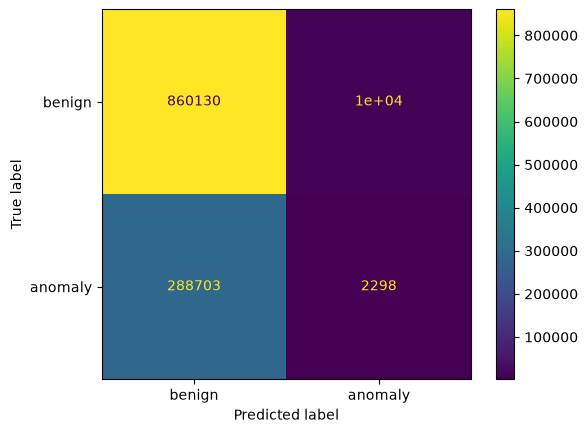

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, preds, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["benign", "anomaly"]).plot()

In [8]:
results = pd.DataFrame({
    "attack": y_test_attackname.values,   # raw string labels you kept
    "pred":   preds,                      # 0/1 from the model
})
# recall per type = fraction of that type's rows flagged as attack (pred==1)
per_type = results[results["attack"] != "BENIGN"].groupby("attack")["pred"].agg(
    recall="mean", n="size"
)
print(per_type.sort_values("recall"))

                             recall       n
attack                                     
Bot                        0.000000    1956
Infiltration               0.000000      36
PortScan                   0.000579  158804
DDoS                       0.006671  128025
Web Attack  Sql Injection  0.333333      21
Web Attack  Brute Force    0.595222    1507
Web Attack  XSS            0.687117     652


In [12]:
probs = xgb_model.predict_proba(X_test)[:, 1]
probs

array([2.8832170e-05, 1.3294962e-04, 4.3324366e-07, ..., 1.7880047e-06,
       1.0786559e-04, 2.2469017e-07], shape=(1161344,), dtype=float32)

In [13]:
threshold = np.percentile(probs, 95)
y_pred_custom = (probs >= threshold).astype(int)
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0], shape=(1161344,))

In [14]:
evaluate(y_pred_custom, y_test, ["benign", "anomaly"], "baseline")

--- baseline ---
accuracy: 0.7610
              precision    recall  f1-score   support

      benign       0.77      0.97      0.86    870343
     anomaly       0.62      0.12      0.20    291001

    accuracy                           0.76   1161344
   macro avg       0.69      0.55      0.53   1161344
weighted avg       0.73      0.76      0.70   1161344



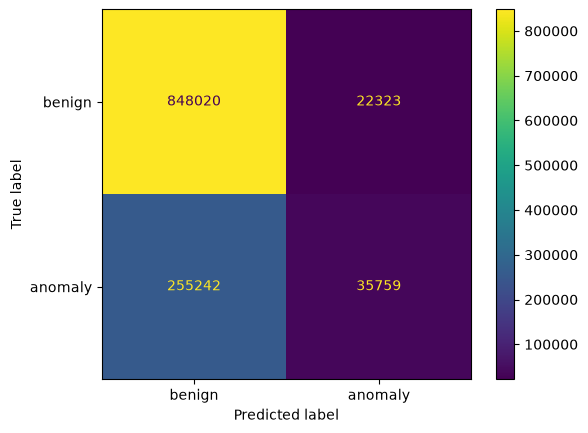

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_custom, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["benign", "anomaly"]).plot()